# Exploratory Data Analysis

This notebook focuses on dataset quality, class balance, transaction behavior,
and leakage-safe temporal feature inspection.

In [8]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from fraudshield.config.settings import get_settings  # noqa: E402
from fraudshield.feature_engineering.transaction_features import (  # noqa: E402
    TransactionFeatureConfig,
    add_transaction_features,
)
from fraudshield.runtime.logging import configure_logging  # noqa: E402

settings = get_settings()
configure_logging(settings, component="notebook_eda")

sns.set_theme(style="whitegrid", context="talk")
data_path = PROJECT_ROOT / "data" / "raw" / "synthetic_fraud_data.csv"
df = pd.read_csv(data_path, parse_dates=["transaction_date"])
df["event_day"] = df["transaction_date"].dt.floor("D")
df.head()

,transaction_id,user_id,merchant_id,transaction_date,amount,currency,status,is_international,is_online,fraud,event_day
0,2215,24,20,2024-01-01 00:14:40,31.63,USD,approved,False,True,0,2024-01-01
1,2084,134,44,2024-01-01 00:19:58,21.31,USD,approved,True,True,0,2024-01-01
2,4932,147,1,2024-01-01 00:46:43,39.81,JPY,approved,True,True,1,2024-01-01
3,4139,177,74,2024-01-01 00:57:57,23.15,USD,reversed,False,True,0,2024-01-01
4,863,25,47,2024-01-01 01:49:23,60.21,GBP,declined,False,False,0,2024-01-01


In [9]:
schema_summary = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_rate": df.isna().mean(),
        "n_unique": df.nunique(dropna=False),
    }
)
schema_summary

,dtype,missing_rate,n_unique
transaction_id,int64,0.0,5000
user_id,int64,0.0,200
merchant_id,int64,0.0,80
transaction_date,datetime64[ns],0.0,4998
amount,float64,0.0,3684
currency,object,0.0,4
status,object,0.0,4
is_international,bool,0.0,2
is_online,bool,0.0,2
fraud,int64,0.0,2


In [10]:
target_summary = (
    df.groupby("fraud")
    .agg(
        transactions=("transaction_id", "count"),
        avg_amount=("amount", "mean"),
        median_amount=("amount", "median"),
        unique_users=("user_id", "nunique"),
        unique_merchants=("merchant_id", "nunique"),
    )
    .round(2)
)
target_summary

,transactions,avg_amount,median_amount,unique_users,unique_merchants
fraud,,,,,
0,4644,44.55,35.02,200,80
1,356,68.69,58.50,158,77


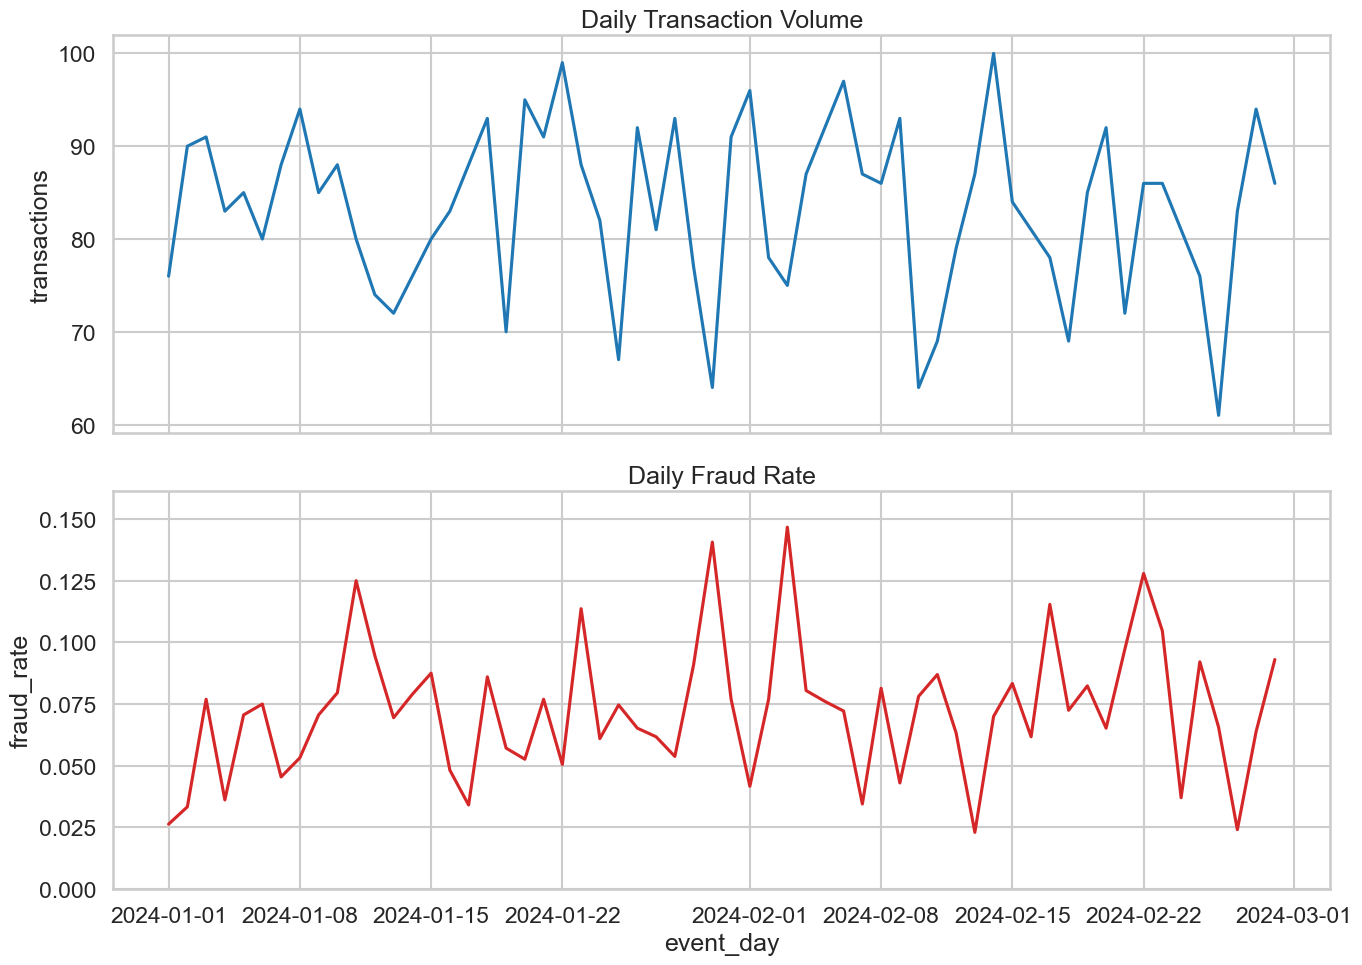

In [11]:
daily_volume = df.groupby("event_day").agg(transactions=("transaction_id", "count"), fraud_rate=("fraud", "mean")).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
sns.lineplot(data=daily_volume, x="event_day", y="transactions", ax=axes[0], color="#1f77b4")
sns.lineplot(data=daily_volume, x="event_day", y="fraud_rate", ax=axes[1], color="#d62728")
axes[0].set_title("Daily Transaction Volume")
axes[1].set_title("Daily Fraud Rate")
axes[1].set_ylim(0, daily_volume["fraud_rate"].max() * 1.1)
plt.tight_layout()

2026-06-15 19:06:48,289 INFO [matplotlib.category] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-15 19:06:48,294 INFO [matplotlib.category] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


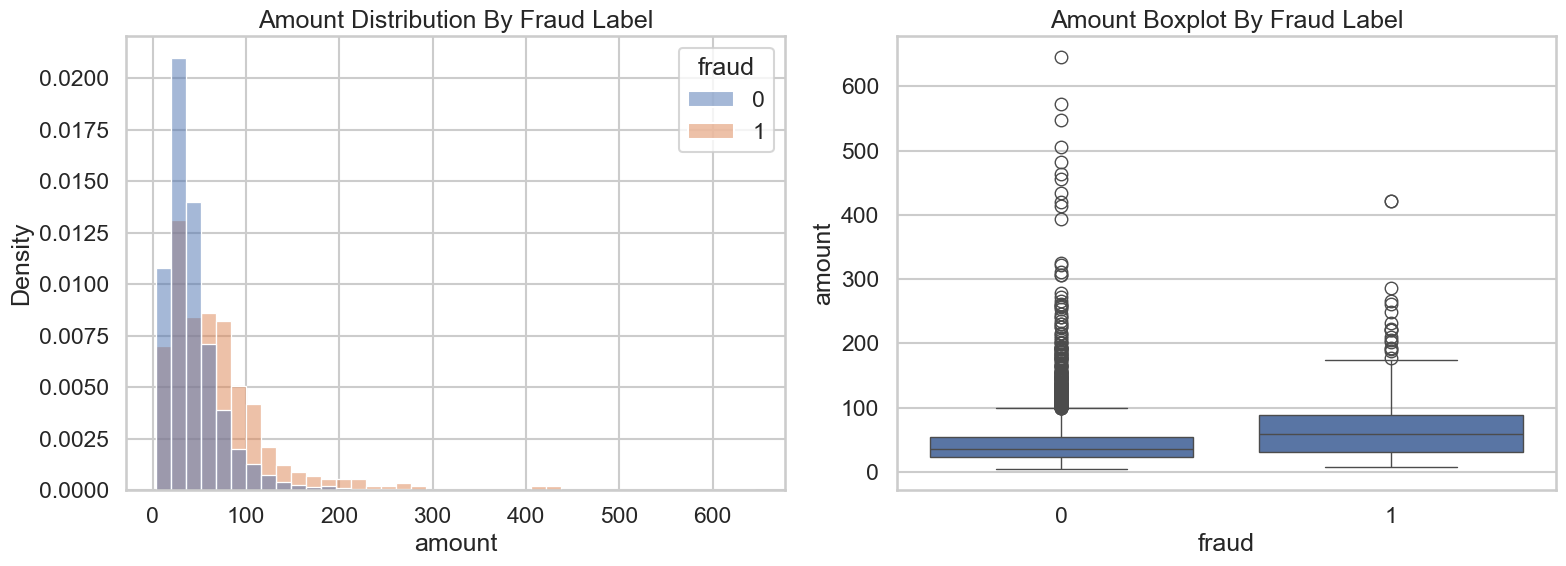

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(data=df, x="amount", hue="fraud", bins=40, stat="density", common_norm=False, ax=axes[0])
sns.boxplot(data=df, x="fraud", y="amount", ax=axes[1])
axes[0].set_title("Amount Distribution By Fraud Label")
axes[1].set_title("Amount Boxplot By Fraud Label")
plt.tight_layout()

In [13]:
merchant_summary = (
    df.groupby("merchant_id")
    .agg(transactions=("transaction_id", "count"), fraud_rate=("fraud", "mean"))
    .query("transactions >= 20")
    .sort_values(["fraud_rate", "transactions"], ascending=[False, False])
    .head(10)
)
merchant_summary

,transactions,fraud_rate
merchant_id,,
51,45,0.200000
27,60,0.166667
74,75,0.160000
12,66,0.151515
39,64,0.140625
68,56,0.125000
48,68,0.117647
59,53,0.113208
57,63,0.111111


In [14]:
feature_df = add_transaction_features(
    df.copy(),
    TransactionFeatureConfig(windows=["1h", "24h", "7d"]),
)

# Explicit fillna for cross-version pandas compatibility
feature_df = feature_df.fillna(0.0)

engineered_columns = [
    "user_time_since_last_txn",
    "user_amount_zscore",
    "user_txn_count_1h",
    "merchant_fraud_rate_24h",
]

# Show rows from the middle of the dataset where features have history
mid = len(feature_df) // 2
print("Feature preview (rows {} to {}):".format(mid, mid + 8))
feature_df[["transaction_id", "transaction_date", *engineered_columns]].iloc[mid:mid + 8]

Feature preview (rows 2500 to 2508):


,transaction_id,transaction_date,user_time_since_last_txn,user_amount_zscore,user_txn_count_1h,merchant_fraud_rate_24h
2500,2134,2024-01-30 21:53:25+00:00,108815.0,1.119658,0.0,0.0
2501,3884,2024-01-30 22:27:38+00:00,57809.0,-0.778243,0.0,0.0
2502,2454,2024-01-30 23:17:27+00:00,33014.0,1.863239,0.0,0.0
2503,1629,2024-01-30 23:39:29+00:00,186453.0,0.302825,0.0,0.0
2504,743,2024-01-30 23:48:11+00:00,128924.0,-0.094261,0.0,0.0
2505,272,2024-01-31 00:12:39+00:00,28771.0,0.718505,0.0,0.0
2506,1962,2024-01-31 00:20:20+00:00,14114.0,0.623186,0.0,0.0
2507,3346,2024-01-31 00:28:36+00:00,53440.0,-0.518847,0.0,0.0


**Note on NaN values**: The first few chronological transactions for each user/merchant
have no prior history, so rolling-window features () and z-scores
() naturally produce NaN. These are filled with 0.0 before model training.
This is a deliberate leakage-prevention design: the model never sees the current
transaction in its own feature computation.

## Analyst Notes

- Start with null rates and entity cardinality before fitting any model.
- Prefer time-aware features such as rolling counts and merchant fraud rates to
  prevent leakage from future observations.
- Keep a minimum support threshold when ranking merchants or users by fraud rate;
  otherwise the analysis overreacts to tiny sample sizes.